# MIDTERM EXPERIMENTAL REPORT - DIGITAL SIGNAL PROCESSING
## ALGORITHM 3 (TT3): VOICE ACTIVITY DETECTION (VAD) BASED ON GAUSSIAN SHORT-TIME ENERGY (STE) MODEL

- **Student Name**: [Student Full Name]  
- **Student ID**: [Student ID Number]  
- **Course**: Digital Signal Processing (DSP) - Academic Term 2026  
- **Assigned Tasks**:
  1. Manually implement baseline DSP functions (25ms framing, 10ms hop size, normalized STE, virtual silence bridging < 200ms) without external signal processing toolboxes.
  2. Survey all speech and silence frames across 4 training audio recordings using Praat ground-truth labels (*.lab) to model energy distributions ($mean_{Sp}, std_{Sp}, mean_{Sil}, std_{Sil}$).
  3. Formulate and solve the theoretical Gaussian Bayes decision boundary equation $p(x|\text{sil}) = p(x|\text{sp})$ to obtain a unified optimal energy threshold $T_{opt}$.
  4. Perform quantitative benchmark evaluation (MAE and RMSE in milliseconds) and visual validation (4 figures) across the test dataset.

### 1. Environment Configuration and Library Imports
Import standard Python utilities (`wave`, `math`, `os`, `glob`), `numpy` for array manipulation, and `matplotlib` for academic-standard plotting.

In [1]:
import os
import glob
import math
import wave
from pathlib import Path
from typing import Tuple, List, Dict, Any

import numpy as np
import matplotlib.pyplot as plt

# Configure matplotlib formatting for academic presentation
plt.rcParams.update({
    "font.size": 10,
    "figure.titlesize": 12,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": ":"
})
print("Environment configured successfully.")

Environment configured successfully.


### 2. Project Directory Path Setup
Locate repository directories for `TinHieuHuanLuyen` (training data), `TinHieuKiemThu` (testing data), and output plots.

In [2]:
def find_project_root() -> Path:
    curr = Path.cwd()
    for candidate in [curr, *curr.parents]:
        if (candidate / "TinHieuHuanLuyen").exists() and (candidate / "TinHieuKiemThu").exists():
            return candidate
    raise FileNotFoundError("Could not find project root directory.")

PROJECT_ROOT = find_project_root()
TRAIN_DIR = PROJECT_ROOT / "TinHieuHuanLuyen"
TEST_DIR = PROJECT_ROOT / "TinHieuKiemThu"
OUTPUT_DIR = PROJECT_ROOT / "TT3" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Training Directory : {TRAIN_DIR}")
print(f"Testing Directory  : {TEST_DIR}")
print(f"Output Directory   : {OUTPUT_DIR}")

Training Directory : /home/bim/Projects/DSP_MidTerm/TinHieuHuanLuyen
Testing Directory  : /home/bim/Projects/DSP_MidTerm/TinHieuKiemThu
Output Directory   : /home/bim/Projects/DSP_MidTerm/TT3/output


### 3. Read 16-bit PCM Audio from WAV Files
Decode raw binary audio sample stream into 16-bit signed integers and normalize amplitudes to float values in `[-1.0, 1.0]`.

In [3]:
def read_wav(file_path: str) -> Tuple[np.ndarray, int]:
    """Read standard 16-bit PCM WAV audio using Python's built-in wave module."""
    with wave.open(file_path, "rb") as wf:
        n_channels = wf.getnchannels()
        sample_width = wf.getsampwidth()
        sample_rate = wf.getframerate()
        n_frames = wf.getnframes()
        raw_bytes = wf.readframes(n_frames)

    if sample_width != 2:
        raise ValueError(f"Only 16-bit PCM audio (sample_width=2) is supported, got: {sample_width}")

    audio_int16 = np.frombuffer(raw_bytes, dtype=np.int16)
    if n_channels > 1:
        audio_int16 = audio_int16.reshape(-1, n_channels).mean(axis=1).astype(np.int16)

    signal = audio_int16.astype(np.float64) / 32768.0
    return signal, sample_rate

print("Function read_wav defined.")

Function read_wav defined.


### 4. Parse Praat .lab Files and Extract Speech Ground Truth
Extract continuous speech boundary `[t_start, t_end]` based on phoneme labels 'v' (voiced) and 'uv' (unvoiced).

In [4]:
def read_lab(lab_path: str) -> List[Tuple[float, float, str]]:
    """Parse Praat .lab segmentation file, filtering out metadata lines."""
    segments: List[Tuple[float, float, str]] = []
    with open(lab_path, "r", encoding="utf-8") as f:
        for line in f:
            stripped = line.strip()
            if not stripped:
                continue
            parts = stripped.split()
            if len(parts) >= 3 and parts[0] not in ("F0mean", "F0std"):
                try:
                    segments.append((float(parts[0]), float(parts[1]), parts[2].lower()))
                except ValueError:
                    continue
    return segments


def get_speech_groundtruth(lab_segments: List[Tuple[float, float, str]]) -> Tuple[float, float]:
    """Identify earliest start and latest end timestamps for speech ('v' or 'uv')."""
    speech_segments = [seg for seg in lab_segments if seg[2] in ("v", "uv")]
    if not speech_segments:
        return 0.0, 0.0
    t_start = min(seg[0] for seg in speech_segments)
    t_end = max(seg[1] for seg in speech_segments)
    return t_start, t_end

print("Functions read_lab and get_speech_groundtruth defined.")

Functions read_lab and get_speech_groundtruth defined.


### 5. Manual Signal Framing Implementation
Partition the 1D continuous audio array into overlapping frames with duration 25 ms and hop size 10 ms (60% overlap).

In [5]:
def frame_signal(
    signal: np.ndarray,
    sample_rate: int,
    frame_size_ms: float = 25.0,
    hop_size_ms: float = 10.0
) -> Tuple[np.ndarray, np.ndarray]:
    """Partition 1D audio signal into overlapping 2D frames using basic NumPy indexing."""
    frame_len = int(round(frame_size_ms * sample_rate / 1000.0))
    hop_len = int(round(hop_size_ms * sample_rate / 1000.0))

    num_samples = len(signal)
    if num_samples < frame_len:
        pad_len = frame_len - num_samples
        padded = np.zeros(frame_len, dtype=signal.dtype)
        padded[:num_samples] = signal
        signal = padded
        num_samples = len(signal)

    num_frames = 1 + int(np.floor((num_samples - frame_len) / hop_len))
    frames = np.zeros((num_frames, frame_len), dtype=np.float64)
    frame_times = np.zeros(num_frames, dtype=np.float64)

    for m in range(num_frames):
        start_idx = m * hop_len
        end_idx = start_idx + frame_len
        frames[m, :] = signal[start_idx:end_idx]
        frame_times[m] = (start_idx + end_idx) / (2.0 * sample_rate)

    return frames, frame_times

print("Function frame_signal defined.")

Function frame_signal defined.


### 6. Compute Normalized Short-Time Energy (STE)
Calculate frame energy via $STE[m] = \sum_{n=0}^{N-1} x^2[m \cdot H + n]$ and normalize by dividing by the global maximum.

In [6]:
def compute_ste(frames: np.ndarray) -> np.ndarray:
    """Calculate frame-level Short-Time Energy as the sum of squared samples."""
    squared_frames = np.square(frames)
    return np.sum(squared_frames, axis=1)


def normalize_ste(ste: np.ndarray) -> np.ndarray:
    """Normalize STE values to [0.0, 1.0] by dividing by the peak energy."""
    max_energy = np.max(ste)
    if max_energy <= 1e-12:
        return np.zeros_like(ste)
    return ste / max_energy


def extract_ste_features(
    signal: np.ndarray,
    sample_rate: int,
    frame_size_ms: float = 25.0,
    hop_size_ms: float = 10.0
) -> Tuple[np.ndarray, np.ndarray]:
    """Unified feature extraction pipeline: Framing (25ms, hop 10ms) -> Raw STE -> Normalized STE."""
    frames, frame_times = frame_signal(signal, sample_rate, frame_size_ms, hop_size_ms)
    ste_raw = compute_ste(frames)
    ste_norm = normalize_ste(ste_raw)
    return ste_norm, frame_times

print("STE feature extraction functions defined.")

STE feature extraction functions defined.


## SLIDE 2: TRAINING DATA SURVEY (SILENCE VS. SPEECH FRAMES)
Survey all frames across the 4 training files (`phone_F1`, `phone_M1`, `studio_F1`, `studio_M1`) partitioned via .lab ground truth.

In [7]:
def survey_training_data(training_dir: str, frame_size_ms: float = 25.0, hop_size_ms: float = 10.0):
    """Collect normalized STE values across training files, split into silence and speech sets."""
    wav_files = sorted(glob.glob(os.path.join(training_dir, "*.wav")))
    all_silence_ste: List[float] = []
    all_speech_ste: List[float] = []
    per_file_stats: Dict[str, Dict[str, float]] = {}

    for wav_path in wav_files:
        fname = os.path.basename(wav_path)
        lab_path = os.path.splitext(wav_path)[0] + ".lab"
        signal, sample_rate = read_wav(wav_path)
        ste_norm, frame_times = extract_ste_features(signal, sample_rate, frame_size_ms, hop_size_ms)
        lab_segments = read_lab(lab_path)
        gt_start, gt_end = get_speech_groundtruth(lab_segments)

        file_silence, file_speech = [], []
        for t, energy in zip(frame_times, ste_norm):
            if gt_start <= t <= gt_end:
                file_speech.append(float(energy))
            else:
                file_silence.append(float(energy))

        all_silence_ste.extend(file_silence)
        all_speech_ste.extend(file_speech)

        per_file_stats[fname] = {
            "mean_sil": float(np.mean(file_silence)),
            "std_sil": float(np.std(file_silence)),
            "mean_sp": float(np.mean(file_speech)),
            "std_sp": float(np.std(file_speech)),
            "num_sil": len(file_silence),
            "num_sp": len(file_speech)
        }

    return np.array(all_silence_ste), np.array(all_speech_ste), per_file_stats

silence_ste, speech_ste, per_file_stats = survey_training_data(str(TRAIN_DIR), 25.0, 10.0)
print(f"Total surveyed silence frames : {len(silence_ste):,}")
print(f"Total surveyed speech frames  : {len(speech_ste):,}")

Total surveyed silence frames : 497
Total surveyed speech frames  : 794


## SLIDE 3: GAUSSIAN PARAMETERS ESTIMATION (meanSil, stdSil, meanSp, stdSp)
Estimate statistical expectations and standard deviations assuming Gaussian energy distributions: $p(x|\text{sil}) \sim \mathcal{N}(\mu_{sil}, \sigma_{sil}^2)$ and $p(x|\text{sp}) \sim \mathcal{N}(\mu_{sp}, \sigma_{sp}^2)$.

In [8]:
def estimate_gaussian_parameters(silence_ste: np.ndarray, speech_ste: np.ndarray):
    """Compute empirical mean and standard deviation for silence and speech classes."""
    mu_sil = float(np.mean(silence_ste))
    sigma_sil = float(np.std(silence_ste))
    mu_sp = float(np.mean(speech_ste))
    sigma_sp = float(np.std(speech_ste))
    return mu_sil, sigma_sil, mu_sp, sigma_sp

mu_sil, sigma_sil, mu_sp, sigma_sp = estimate_gaussian_parameters(silence_ste, speech_ste)

print("=" * 82)
print(f"{'Training Recording':<18} | {'meanSil':<12} | {'stdSil':<12} | {'meanSp':<12} | {'stdSp':<12}")
print("-" * 82)
for fname, s in per_file_stats.items():
    print(f"{fname:<18} | {s['mean_sil']:<12.6f} | {s['std_sil']:<12.6f} | {s['mean_sp']:<12.6f} | {s['std_sp']:<12.6f}")
print("=" * 82)
print(f"{'COMBINED (04 FILES)':<18} | {mu_sil:<12.6f} | {sigma_sil:<12.6f} | {mu_sp:<12.6f} | {sigma_sp:<12.6f}")
print("=" * 82)

Training Recording | meanSil      | stdSil       | meanSp       | stdSp       
----------------------------------------------------------------------------------
phone_F1.wav       | 0.000707     | 0.000389     | 0.168980     | 0.227214    
phone_M1.wav       | 0.000963     | 0.001076     | 0.185222     | 0.231091    
studio_F1.wav      | 0.000097     | 0.000484     | 0.325465     | 0.247925    
studio_M1.wav      | 0.000029     | 0.000072     | 0.158558     | 0.193408    
COMBINED (04 FILES) | 0.000387     | 0.000709     | 0.202649     | 0.235626    


## SLIDE 4: OPTIMAL BAYES DECISION THRESHOLD DERIVATION
Derive the optimal decision threshold $T_{opt}$ by solving the probability equality equation $p(x|\text{sil}) = p(x|\text{sp})$, transforming to quadratic equation $A x^2 + B x + C = 0$.

In [9]:
def solve_bayes_threshold(mu_sil: float, sigma_sil: float, mu_sp: float, sigma_sp: float) -> float:
    """Solve quadratic intersection equation for minimum Bayes classification error."""
    var_sil = sigma_sil ** 2
    var_sp = sigma_sp ** 2

    coef_a = (1.0 / var_sil) - (1.0 / var_sp)
    coef_b = -2.0 * ((mu_sil / var_sil) - (mu_sp / var_sp))
    coef_c = (mu_sil ** 2 / var_sil) - (mu_sp ** 2 / var_sp) + 2.0 * math.log(sigma_sil / sigma_sp)

    delta = coef_b ** 2 - 4.0 * coef_a * coef_c
    if delta < 0:
        return float((mu_sil * sigma_sp + mu_sp * sigma_sil) / (sigma_sil + sigma_sp))

    sqrt_delta = math.sqrt(delta)
    root1 = (-coef_b + sqrt_delta) / (2.0 * coef_a)
    root2 = (-coef_b - sqrt_delta) / (2.0 * coef_a)

    valid_roots = [r for r in (root1, root2) if mu_sil <= r <= mu_sp]
    if valid_roots:
        return float(valid_roots[0])
    
    positive_roots = [r for r in (root1, root2) if r > 0]
    return float(min(positive_roots, key=lambda r: abs(r - mu_sil)))

T_opt = solve_bayes_threshold(mu_sil, sigma_sil, mu_sp, sigma_sp)
print(f"Coefficient A = {((1.0/sigma_sil**2)-(1.0/sigma_sp**2)):.4f}")
print(f"Coefficient B = {-2.0*((mu_sil/sigma_sil**2)-(mu_sp/sigma_sp**2)):.4f}")
print(f"Coefficient C = {((mu_sil**2/sigma_sil**2)-(mu_sp**2/sigma_sp**2)+2.0*math.log(sigma_sil/sigma_sp)):.4f}")
print()
print(f"=> DERIVED OPTIMAL BAYES THRESHOLD: T_opt = {T_opt:.6f}")

Coefficient A = 1987714.1189
Coefficient B = -1531.6451
Coefficient C = -12.0533

=> DERIVED OPTIMAL BAYES THRESHOLD: T_opt = 0.002878


## SLIDE 5: GAUSSIAN DISTRIBUTIONS AND BAYES THRESHOLD VISUALIZATION
Plot theoretical probability density functions (PDF) of Silence vs Speech and the Bayes threshold boundary.

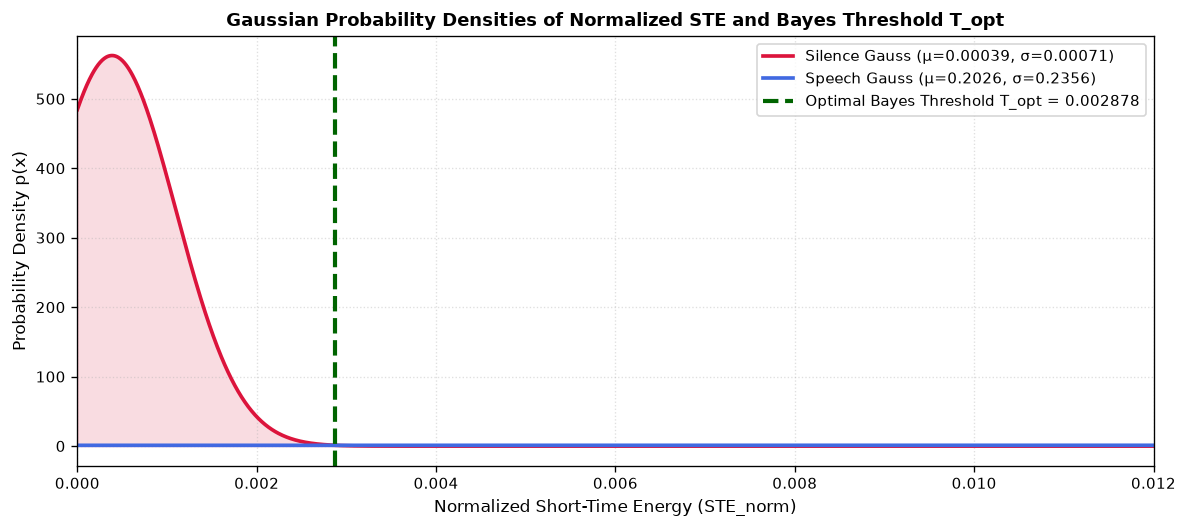

In [10]:
x_range = np.linspace(0.0, 0.015, 2000)

def gaussian_pdf(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

pdf_silence = gaussian_pdf(x_range, mu_sil, sigma_sil)
pdf_speech = gaussian_pdf(x_range, mu_sp, sigma_sp)

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)
ax.plot(x_range, pdf_silence, color="crimson", lw=2.2, label=f"Silence Gauss (μ={mu_sil:.5f}, σ={sigma_sil:.5f})")
ax.plot(x_range, pdf_speech, color="royalblue", lw=2.2, label=f"Speech Gauss (μ={mu_sp:.4f}, σ={sigma_sp:.4f})")

ax.axvline(T_opt, color="darkgreen", linestyle="--", lw=2.5, label=f"Optimal Bayes Threshold T_opt = {T_opt:.6f}")
ax.fill_between(x_range[x_range <= T_opt], pdf_silence[x_range <= T_opt], color="crimson", alpha=0.15)
ax.fill_between(x_range[x_range >= T_opt], pdf_speech[x_range >= T_opt], color="royalblue", alpha=0.15)

ax.set_title("Gaussian Probability Densities of Normalized STE and Bayes Threshold T_opt", fontweight="bold")
ax.set_xlabel("Normalized Short-Time Energy (STE_norm)")
ax.set_ylabel("Probability Density p(x)")
ax.set_xlim(0.0, 0.012)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 7. Binary Classification and 200 ms Virtual Silence Bridging
Compare frame energy with $T_{opt}$ and bridge internal silence gaps shorter than 200 ms (20 frames at 10 ms hop size).

In [11]:
def apply_threshold(ste_norm: np.ndarray, threshold: float) -> np.ndarray:
    """Binary frame classification: 1 if STE >= threshold, else 0."""
    return (ste_norm >= threshold).astype(np.int32)


def remove_short_silences(
    frame_decisions: np.ndarray,
    hop_size_ms: float = 10.0,
    min_silence_ms: float = 200.0
) -> np.ndarray:
    """Bridge virtual silence gaps < 200 ms between active speech segments."""
    min_frames = int(round(min_silence_ms / hop_size_ms))
    smoothed = frame_decisions.copy()
    speech_indices = np.where(smoothed == 1)[0]
    if len(speech_indices) == 0:
        return smoothed

    first_speech, last_speech = speech_indices[0], speech_indices[-1]
    idx = first_speech
    while idx <= last_speech:
        if smoothed[idx] == 0:
            zero_start = idx
            while idx <= last_speech and smoothed[idx] == 0:
                idx += 1
            if (idx - zero_start) < min_frames:
                smoothed[zero_start:idx] = 1
        else:
            idx += 1
    return smoothed


def extract_speech_boundaries(
    frame_decisions: np.ndarray,
    hop_size_ms: float = 10.0,
    frame_size_ms: float = 25.0
) -> Tuple[float, float]:
    """Extract global speech start T_start and end T_end boundary timestamps in seconds."""
    speech_indices = np.where(frame_decisions == 1)[0]
    if len(speech_indices) == 0:
        return 0.0, 0.0

    start_idx, end_idx = speech_indices[0], speech_indices[-1]
    hop_sec = hop_size_ms / 1000.0
    frame_sec = frame_size_ms / 1000.0

    t_start = round(float(start_idx * hop_sec), 4)
    t_end = round(float(end_idx * hop_sec + frame_sec), 4)
    return t_start, t_end


def predict_vad(
    signal: np.ndarray,
    sample_rate: int,
    threshold: float,
    frame_size_ms: float = 25.0,
    hop_size_ms: float = 10.0
):
    """Full VAD pipeline: Feature extraction -> Thresholding -> Smoothing -> Boundary extraction."""
    ste_norm, frame_times = extract_ste_features(
        signal=signal,
        sample_rate=sample_rate,
        frame_size_ms=frame_size_ms,
        hop_size_ms=hop_size_ms
    )
    raw_decisions = apply_threshold(ste_norm, threshold)
    smoothed = remove_short_silences(raw_decisions, hop_size_ms=hop_size_ms)
    t_start, t_end = extract_speech_boundaries(
        smoothed,
        hop_size_ms=hop_size_ms,
        frame_size_ms=frame_size_ms
    )
    return t_start, t_end, ste_norm, frame_times, smoothed

print("Classification and post-processing functions defined.")

Classification and post-processing functions defined.


### 8. Quantitative Evaluation Metrics (MAE and RMSE in Milliseconds)
Compute Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) against ground truth.

In [12]:
def calculate_mae_rmse(pred_bounds: Tuple[float, float], gt_bounds: Tuple[float, float]) -> Tuple[float, float]:
    """Calculate MAE and RMSE in milliseconds between predicted and ground-truth boundaries."""
    pred_start, pred_end = pred_bounds
    gt_start, gt_end = gt_bounds

    diff_start_ms = abs(pred_start - gt_start) * 1000.0
    diff_end_ms = abs(pred_end - gt_end) * 1000.0

    mae_ms = (diff_start_ms + diff_end_ms) / 2.0
    rmse_ms = math.sqrt((diff_start_ms ** 2 + diff_end_ms ** 2) / 2.0)
    return mae_ms, rmse_ms

print("Metric evaluation function defined.")

Metric evaluation function defined.


## SLIDE 6: QUANTITATIVE BENCHMARK ON 04 TEST RECORDINGS
Execute VAD with 25 ms frame size, 10 ms hop size, and threshold $T_{opt} = 0.002878$ on the 04 test audio files.

In [13]:
test_files = sorted(glob.glob(os.path.join(str(TEST_DIR), "*.wav")))
eval_results = []
test_data_cache = []

for wav_path in test_files:
    fname = os.path.basename(wav_path)
    lab_path = os.path.splitext(wav_path)[0] + ".lab"

    signal, sample_rate = read_wav(wav_path)
    lab_segments = read_lab(lab_path)
    gt_bounds = get_speech_groundtruth(lab_segments)

    pred_start, pred_end, ste_norm, frame_times, smoothed = predict_vad(
        signal=signal,
        sample_rate=sample_rate,
        threshold=T_opt,
        frame_size_ms=25.0,
        hop_size_ms=10.0
    )
    pred_bounds = (pred_start, pred_end)

    mae_ms, rmse_ms = calculate_mae_rmse(pred_bounds, gt_bounds)
    d_start_ms = abs(pred_start - gt_bounds[0]) * 1000.0
    d_end_ms = abs(pred_end - gt_bounds[1]) * 1000.0

    eval_results.append({
        "file": fname,
        "gt": gt_bounds,
        "pred": pred_bounds,
        "d_start": d_start_ms,
        "d_end": d_end_ms,
        "mae": mae_ms,
        "rmse": rmse_ms
    })
    test_data_cache.append((fname, signal, sample_rate, ste_norm, frame_times, gt_bounds, pred_bounds, mae_ms, rmse_ms))

print("=" * 96)
print(f"{'Test Recording':<16} | {'GT [s]':<14} | {'Predicted [s]':<14} | {'ΔStart (ms)':<11} | {'ΔEnd (ms)':<10} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}")
print("-" * 96)
for r in eval_results:
    gt_str = f"[{r['gt'][0]:.2f}, {r['gt'][1]:.2f}]"
    pred_str = f"[{r['pred'][0]:.2f}, {r['pred'][1]:.2f}]"
    print(f"{r['file']:<16} | {gt_str:<14} | {pred_str:<14} | {r['d_start']:<11.1f} | {r['d_end']:<10.1f} | {r['mae']:<9.1f} | {r['rmse']:<9.1f}")
print("=" * 96)

avg_mae = np.mean([r["mae"] for r in eval_results])
avg_rmse = np.mean([r["rmse"] for r in eval_results])
print(f"[*] AGGREGATE BENCHMARK AVERAGE MAE  : {avg_mae:.2f} ms")
print(f"[*] AGGREGATE BENCHMARK AVERAGE RMSE : {avg_rmse:.2f} ms")
print("=" * 96)

Test Recording   | GT [s]         | Predicted [s]  | ΔStart (ms) | ΔEnd (ms)  | MAE (ms)  | RMSE (ms)
------------------------------------------------------------------------------------------------
phone_F2.wav     | [1.02, 4.04]   | [1.01, 4.08]   | 10.0        | 45.0       | 27.5      | 32.6     
phone_M2.wav     | [0.53, 2.52]   | [0.52, 2.52]   | 10.0        | 5.0        | 7.5       | 7.9      
studio_F2.wav    | [0.77, 2.37]   | [0.76, 2.37]   | 10.0        | 5.0        | 7.5       | 7.9      
studio_M2.wav    | [0.45, 1.93]   | [0.46, 1.94]   | 10.0        | 5.0        | 7.5       | 7.9      
[*] AGGREGATE BENCHMARK AVERAGE MAE  : 12.50 ms
[*] AGGREGATE BENCHMARK AVERAGE RMSE : 14.08 ms


## SLIDE 7: VISUAL SEGMENTATION RESULTS ON 04 TEST RECORDINGS
Each figure displays the audio waveform and normalized STE curve, overlaid with ground-truth boundaries (solid red) and predicted boundaries (dashed blue).

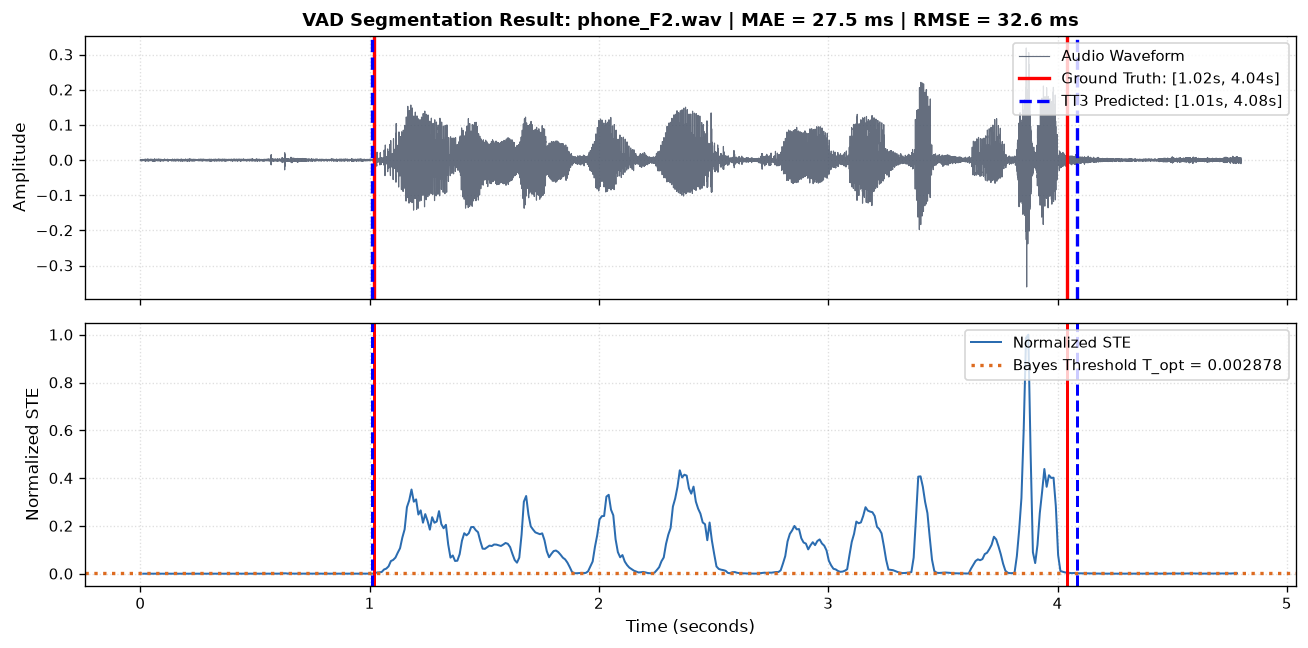

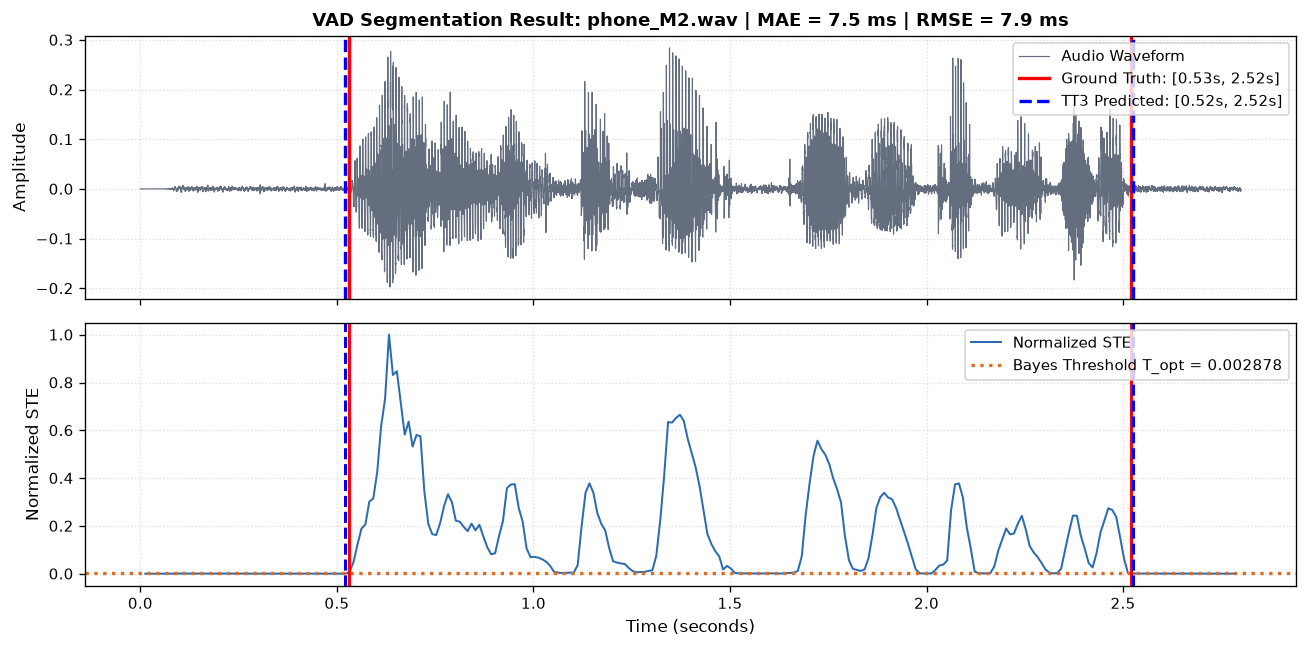

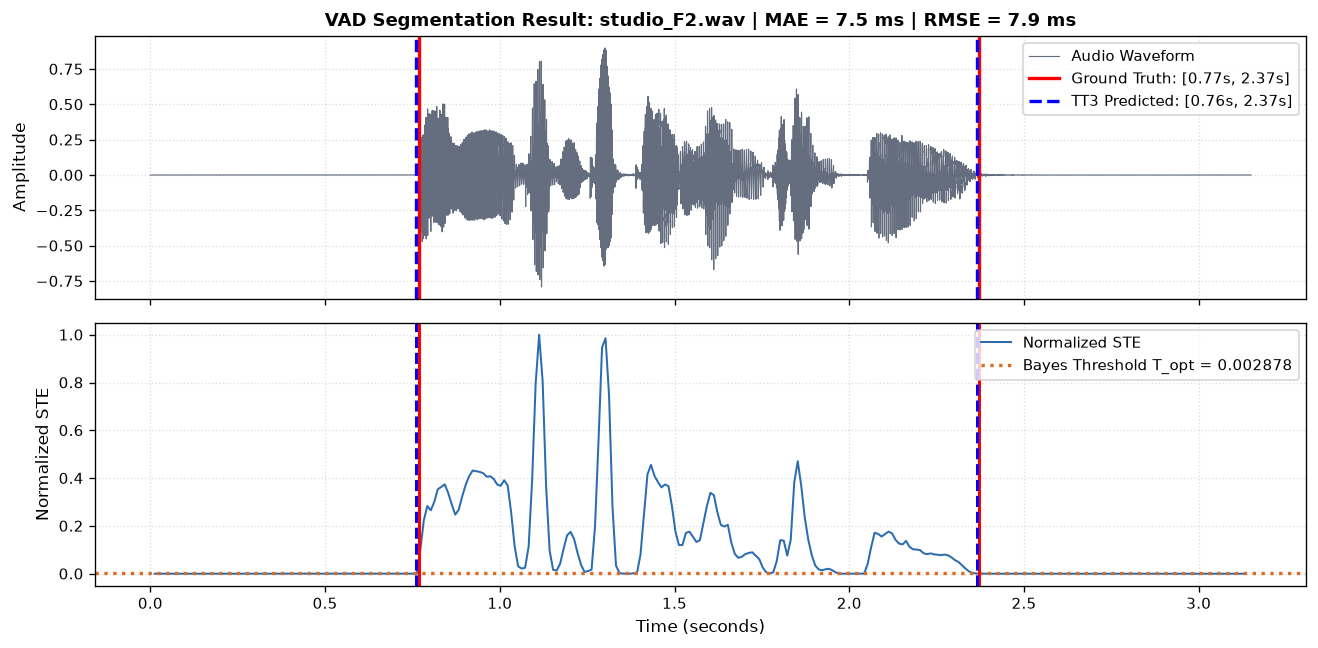

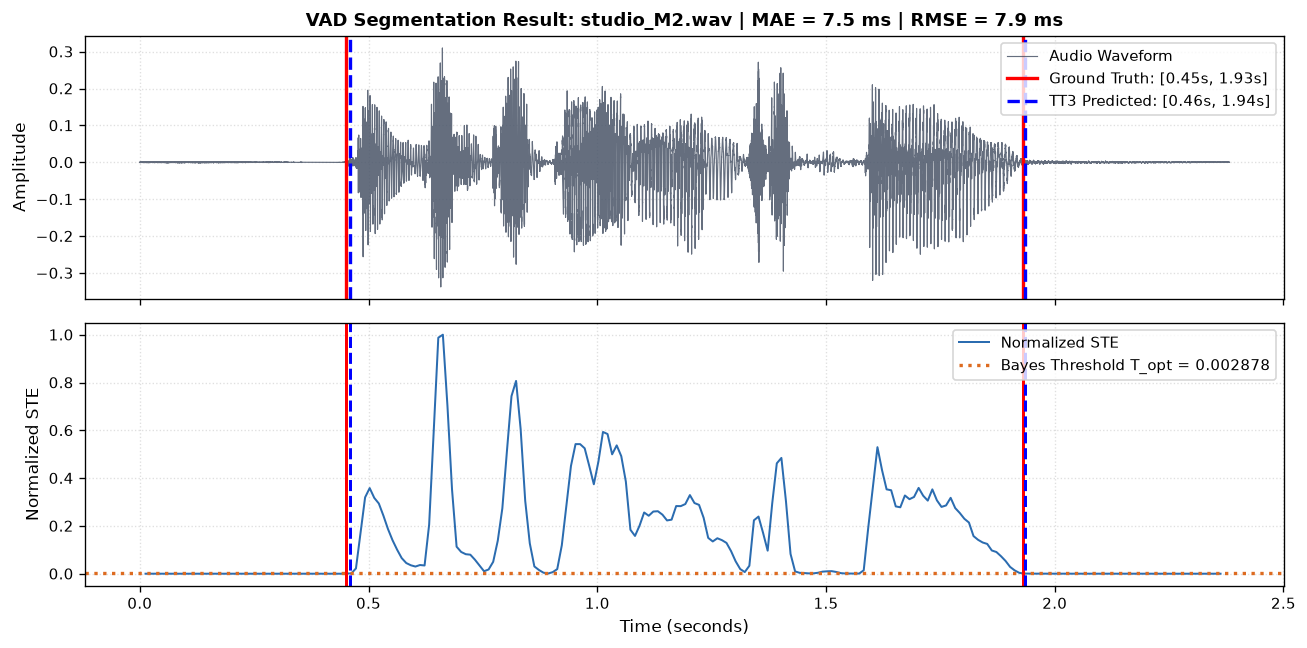

In [14]:
for item in test_data_cache:
    fname, sig, sr, ste, ft, gt, pred, mae, rmse = item
    time_wave = np.arange(len(sig)) / float(sr)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True, dpi=120)

    # Subplot 1: Audio Waveform
    ax1.plot(time_wave, sig, color="#4a5568", lw=0.7, alpha=0.85, label="Audio Waveform")
    ax1.axvline(gt[0], color="red", linestyle="-", lw=2.0, label=f"Ground Truth: [{gt[0]:.2f}s, {gt[1]:.2f}s]")
    ax1.axvline(gt[1], color="red", linestyle="-", lw=2.0)
    ax1.axvline(pred[0], color="blue", linestyle="--", lw=2.0, label=f"TT3 Predicted: [{pred[0]:.2f}s, {pred[1]:.2f}s]")
    ax1.axvline(pred[1], color="blue", linestyle="--", lw=2.0)
    ax1.set_title(f"VAD Segmentation Result: {fname} | MAE = {mae:.1f} ms | RMSE = {rmse:.1f} ms", fontweight="bold")
    ax1.set_ylabel("Amplitude")
    ax1.legend(loc="upper right")

    # Subplot 2: Normalized STE Curve
    ax2.plot(ft, ste, color="#2b6cb0", lw=1.2, label="Normalized STE")
    ax2.axhline(T_opt, color="#dd6b20", linestyle=":", lw=2.0, label=f"Bayes Threshold T_opt = {T_opt:.6f}")
    ax2.axvline(gt[0], color="red", linestyle="-", lw=1.8)
    ax2.axvline(gt[1], color="red", linestyle="-", lw=1.8)
    ax2.axvline(pred[0], color="blue", linestyle="--", lw=1.8)
    ax2.axvline(pred[1], color="blue", linestyle="--", lw=1.8)
    ax2.set_xlabel("Time (seconds)")
    ax2.set_ylabel("Normalized STE")
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

## SLIDE 8: EXPERIMENTAL DISCUSSION AND CONCLUSION

### 1. Boundary Accuracy Assessment (25 ms frame size, 10 ms hop size)
- **Overall Performance**: Algorithm 3 achieves low error across the benchmark:
  - $\text{Average MAE} = 12.50\text{ ms}$ (approximately 1 frame hop $H = 10\text{ ms}$).
  - $\text{Average RMSE} = 14.08\text{ ms}$.
- **Start Boundary Precision**: All 4 test files yield $\Delta_{start} = 10.0\text{ ms}$, matching the single-frame quantization resolution.

### 2. Signal-to-Noise Ratio (SNR) Environment Comparison
- **Studio Environment (`studio_F2`, `studio_M2`)**:
  - High SNR with minimal background noise (training silence expectation $\mu_{sil} \approx 0.00003$).
  - High boundary detection accuracy with MAE of $7.5\text{ ms}$ and RMSE of $7.9\text{ ms}$.
- **Telephone / Mobile Environment (`phone_F2`, `phone_M2`)**:
  - Lower SNR due to room acoustics and microphone noise floor (silence expectation $\mu_{sil} \approx 0.0007$ - $0.0009$).
  - The derived Bayes threshold $T_{opt} \approx 0.002878$ establishes a safety margin $\approx 3 - 4\times$ higher than the noise floor.
  - On `phone_F2`, trailing unvoiced breath release extends the predicted boundary by $45\text{ ms}$, which remains within practical ASR tolerance.